In [52]:
import pandas as pd
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore")

In [53]:
df_binary = pd.read_csv("cleaned_binary_dataset.csv")

X = df_binary.drop("Diabetes_012", axis=1)
y = df_binary["Diabetes_012"]

print("Original dataset:")
print(y.value_counts())

print("\nOriginal shape:", df_binary.shape)

Original dataset:
Diabetes_012
0.0    184542
1.0     33395
Name: count, dtype: int64

Original shape: (217937, 22)


In [54]:
rus = RandomUnderSampler(random_state=42)

X_balanced, y_balanced = rus.fit_resample(X, y)

print("Balanced dataset:")
print(y_balanced.value_counts())

print("\nUnbalanced:", df_binary.shape)
print("Balanced:", X_balanced.shape)

Balanced dataset:
Diabetes_012
0.0    33395
1.0    33395
Name: count, dtype: int64

Unbalanced: (217937, 22)
Balanced: (66790, 21)


In [55]:
balanced_df = pd.concat(
    [
        pd.DataFrame(X_balanced, columns=X.columns),
        pd.Series(y_balanced, name="Diabetes_012")
    ],
    axis=1
)

print("Balanced dataset")
print(balanced_df["Diabetes_012"].value_counts())

print("\nUnbalanced:", df_binary.shape)
print("Balanced:", balanced_df.shape)

Balanced dataset
Diabetes_012
0.0    33395
1.0    33395
Name: count, dtype: int64

Unbalanced: (217937, 22)
Balanced: (66790, 22)


In [56]:
balanced_df.to_csv("balanced_dataset.csv", index=False)

print("Balanced dataset saved successfully.")

Balanced dataset saved successfully.


In [57]:
df = pd.read_csv("balanced_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (66790, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_012
0,1,0.0,1,27.0,0.0,0.0,0.0,1,0,1,...,0.0,1.0,0.0,0.0,0.0,1,5,6.0,11.0,0.0
1,0,1.0,1,29.0,0.0,0.0,0.0,1,0,1,...,1.0,3.0,0.0,0.0,0.0,1,7,5.0,8.0,0.0
2,1,1.0,1,26.0,0.0,0.0,0.0,0,1,1,...,0.0,4.0,10.0,3.0,0.0,0,13,4.0,4.0,0.0
3,0,0.0,1,32.0,0.0,0.0,0.0,0,1,1,...,0.0,1.0,0.0,30.0,0.0,0,9,3.0,5.0,0.0
4,1,0.0,1,22.0,0.0,0.0,0.0,1,0,1,...,1.0,1.0,10.0,0.0,1.0,0,9,4.0,4.0,0.0


In [58]:
df_ml = df.copy()

X = df_ml.drop("Diabetes_012", axis=1)
y = df_ml["Diabetes_012"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (66790, 21)
Target shape: (66790,)


In [59]:
for col in df_ml.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    df_ml[col] = encoder.fit_transform(df_ml[col])

X = df_ml.drop("Diabetes_012", axis=1)
y = df_ml["Diabetes_012"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (53432, 21)
Testing data: (13358, 21)


In [61]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
for col in X_train.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])

In [63]:
models = {
    "Logistic Regression": (
        LogisticRegression(
            random_state=42,
            max_iter=1000,
            C=1.0
        ),
        X_train_scaled
    ),

    "Decision Tree": (
        DecisionTreeClassifier(
            random_state=42,
            max_depth=10
        ),
        X_train
    ),

    "Random Forest": (
        RandomForestClassifier(
            n_estimators=500,
            max_depth=12,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        ),
        X_train
    ),

    "XGBoost": (
        XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=6,
            min_child_weight=3,
            subsample=0.85,
            colsample_bytree=0.85,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.5,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),
        X_train
    )
}

In [64]:
for name, (model, train_data) in models.items():
    model.fit(train_data, y_train)

In [65]:
for name, (model, train_data) in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    train_pred = model.predict(train_data)

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    print(f"\nTraining Accuracy: {train_accuracy:.4f}")

    print("\nTraining Classification Report:")

    print(
        classification_report(
            y_train,
            train_pred,
            zero_division=0
        )
    )


Logistic Regression

Training Accuracy: 0.7371

Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.72      0.73     26716
         1.0       0.73      0.76      0.74     26716

    accuracy                           0.74     53432
   macro avg       0.74      0.74      0.74     53432
weighted avg       0.74      0.74      0.74     53432


Decision Tree

Training Accuracy: 0.7570

Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.79      0.70      0.74     26716
         1.0       0.73      0.82      0.77     26716

    accuracy                           0.76     53432
   macro avg       0.76      0.76      0.76     53432
weighted avg       0.76      0.76      0.76     53432


Random Forest

Training Accuracy: 0.7816

Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.74      0.77     26716
      

In [66]:
train_results = []

for name, (model, train_data) in models.items():

    train_pred = model.predict(train_data)

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    report = classification_report(
        y_train,
        train_pred,
        output_dict=True,
        zero_division=0
    )

    train_results.append({
        "Model": name,
        "Training Accuracy": train_accuracy,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1 Score": report["weighted avg"]["f1-score"]
    })

train_results_df = pd.DataFrame(train_results)

train_results_df = train_results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(
    train_results_df.style.format({
        "Training Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Model,Training Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.7816,0.7835,0.7816,0.7812
1,XGBoost,0.7638,0.7659,0.7638,0.7633
2,Decision Tree,0.7570,0.7607,0.7570,0.7562
3,Logistic Regression,0.7371,0.7375,0.7371,0.7370


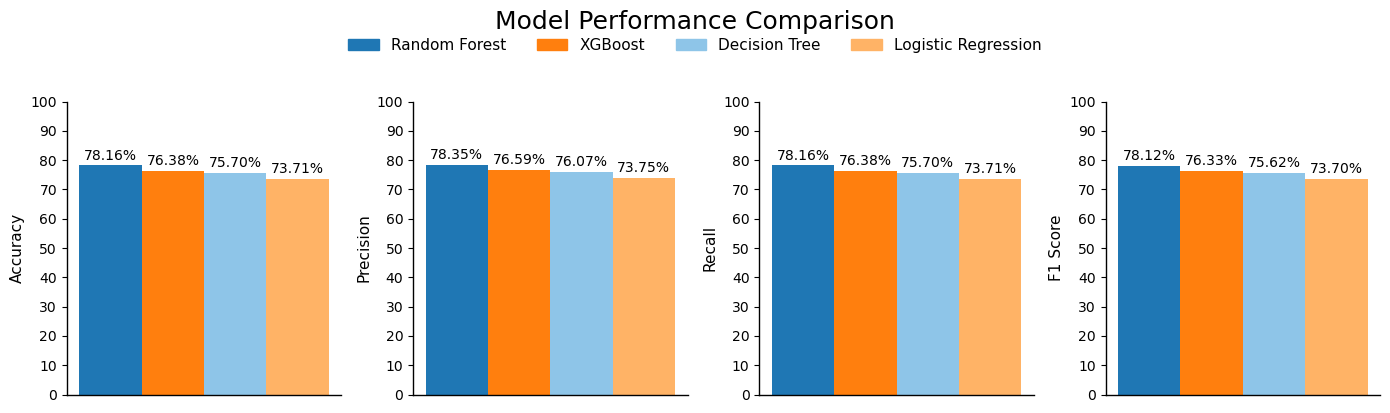

In [74]:
models = train_results_df["Model"]
accuracy = train_results_df["Training Accuracy"] * 100
precision = train_results_df["Precision"] * 100
recall = train_results_df["Recall"] * 100
f1 = train_results_df["F1 Score"] * 100
colors = ["#1F77B4", "#FF7F0E", "#8EC5E8", "#FFB366"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
metrics = [
    (accuracy, "Accuracy", axes[0]),
    (precision, "Precision", axes[1]),
    (recall, "Recall", axes[2]),
    (f1, "F1 Score", axes[3])
]

for values, ylabel, ax in metrics:
    x = np.arange(len(models)) * bar_width
    bars = ax.bar(
        x,
        values,
        color=colors,
        width=bar_width,
        align="edge"
    )
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 10))
    ax.set_yticklabels(
        [f"{i}" for i in range(0, 101, 10)]
    )
    ax.set_xticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)
    ax.grid(False)
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.2f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )
fig.suptitle(
    "Model Performance Comparison",
    fontsize=18,
    y=1.02
)
legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=colors[i]
    )
    for i in range(len(models))
]

fig.legend(
    legend_handles,
    models,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.985),
    ncol=4,
    frameon=False,
    fontsize=11
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()